In [31]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, classification_report
import matplotlib.pyplot as plt

In [32]:
# 1. Load the Model-Ready Data
df = pd.read_parquet('C:/Users/Sam Garcia/PycharmProjects/macro_alpha/data/processed/train_ready_features.parquet')             

In [33]:
# 2. Separate Features (X) and Target (y)
X = df.drop(columns=['target_5d_up'])
y = df['target_5d_up']

In [34]:
# 3. Initialize Time Series Split (Walk-Forward Validation)
# We use 5 splits. This simulates deploying the model 5 different times in history.
tscv = TimeSeriesSplit(n_splits=5)

In [35]:
# 4. Initialize Baseline XGBoost (Conservative settings for finance)
model = XGBClassifier(
    tree_method="hist",        # recommended for enable_categorical
    enable_categorical=True,
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,        # Keep it shallow! Financial data is noisy.
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

### The Data Scientist Lens

In [36]:
# 5. The Training Loop
accuracies = []
precisions = []

print("🚀 Starting Time-Series Walk-Forward Validation...\n")

for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Train the model on the past
    model.fit(X_train, y_train)
    
    # Predict the future
    preds = model.predict(X_test)
    
    # Calculate metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds) # Precision: When it says "UP", how often is it right?
    
    accuracies.append(acc)
    precisions.append(prec)
    
    # To understand the environment of this fold, let's look at the naive baseline
    fold_baseline = y_test.mean() 
    
    print(f"--- Fold {fold + 1} ---")
    print(f"Test Period: {X_test.index.min().date()} to {X_test.index.max().date()}")
    print(f"Dumb Baseline (Always Buy): {fold_baseline:.2%}")
    print(f"Model Accuracy:             {acc:.2%}")
    print(f"Model Precision:            {prec:.2%}\n")

print("=========================================")
print(f"📊 Average Model Accuracy:  {np.mean(accuracies):.2%}")
print(f"📊 Average Model Precision: {np.mean(precisions):.2%}")
print("=========================================")

🚀 Starting Time-Series Walk-Forward Validation...

--- Fold 1 ---
Test Period: 2013-05-28 to 2015-12-07
Dumb Baseline (Always Buy): 57.90%
Model Accuracy:             50.55%
Model Precision:            56.59%

--- Fold 2 ---
Test Period: 2015-12-08 to 2018-06-21
Dumb Baseline (Always Buy): 61.97%
Model Accuracy:             48.04%
Model Precision:            59.76%

--- Fold 3 ---
Test Period: 2018-06-22 to 2021-01-05
Dumb Baseline (Always Buy): 64.16%
Model Accuracy:             56.65%
Model Precision:            63.77%

--- Fold 4 ---
Test Period: 2021-01-06 to 2023-07-21
Dumb Baseline (Always Buy): 57.43%
Model Accuracy:             53.52%
Model Precision:            56.97%

--- Fold 5 ---
Test Period: 2023-07-24 to 2026-02-06
Dumb Baseline (Always Buy): 61.82%
Model Accuracy:             62.91%
Model Precision:            63.57%

📊 Average Model Accuracy:  54.33%
📊 Average Model Precision: 60.13%


### The Portfolio Manager Lens

In [37]:
print("🚀 Starting Corrected Long/Cash Backtest...\n")

portfolio_returns = []
baseline_returns = []

# FIX 1: We must capture TOMORROW'S return. 
# Shift the daily returns up by 1. 
df['future_1d_return'] = df['daily_return'].shift(-1)

for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Grab the aligned future returns for our test period
    fold_future_returns = df['future_1d_return'].iloc[test_index]
    
    model.fit(X_train, y_train)
    
    # Get probabilities
    probs = model.predict_proba(X_test)[:, 1] 
    
    # FIX 2: Long or Cash strategy. NO SHORTING.
    # If confidence is > 55%, be in the market (1). Otherwise, hide in cash (0).
    signals = np.where(probs > 0.55, 1, 0)
    
    # Calculate Strategy Returns (Signal * Tomorrow's Return)
    strategy_returns = signals * fold_future_returns
    
    # Clean up any NaNs at the very end of the dataset
    strategy_returns = strategy_returns.fillna(0)
    fold_future_returns = fold_future_returns.fillna(0)
    
    # Cumulative sum
    fold_strat_return = strategy_returns.sum()
    fold_base_return = fold_future_returns.sum() 
    
    print(f"--- Fold {fold + 1} ({X_test.index.min().date()} to {X_test.index.max().date()}) ---")
    print(f"Days Invested: {(signals == 1).sum()} / {len(signals)} days")
    print(f"Buy & Hold Return:  {fold_base_return:.2%}")
    print(f"Strategy Return:    {fold_strat_return:.2%}\n")
    
    portfolio_returns.extend(strategy_returns.tolist())
    baseline_returns.extend(fold_future_returns.tolist())

# Final Metrics
port_returns_series = pd.Series(portfolio_returns)
base_returns_series = pd.Series(baseline_returns)

strat_sharpe = (port_returns_series.mean() / port_returns_series.std()) * np.sqrt(252)
base_sharpe = (base_returns_series.mean() / base_returns_series.std()) * np.sqrt(252)

print("=========================================")
print(f"📊 Total Buy & Hold Return: {base_returns_series.sum():.2%}")
print(f"📊 Total Strategy Return:   {port_returns_series.sum():.2%}")
print(f"📈 Buy & Hold Sharpe:       {base_sharpe:.2f}")
print(f"📈 Strategy Sharpe:         {strat_sharpe:.2f}")
print("=========================================")

🚀 Starting Corrected Long/Cash Backtest...

--- Fold 1 (2013-05-28 to 2015-12-07) ---
Days Invested: 325 / 639 days
Buy & Hold Return:  23.88%
Strategy Return:    8.60%

--- Fold 2 (2015-12-08 to 2018-06-21) ---
Days Invested: 248 / 639 days
Buy & Hold Return:  30.73%
Strategy Return:    16.93%

--- Fold 3 (2018-06-22 to 2021-01-05) ---
Days Invested: 394 / 639 days
Buy & Hold Return:  38.38%
Strategy Return:    22.92%

--- Fold 4 (2021-01-06 to 2023-07-21) ---
Days Invested: 439 / 639 days
Buy & Hold Return:  23.79%
Strategy Return:    29.98%

--- Fold 5 (2023-07-24 to 2026-02-06) ---
Days Invested: 518 / 639 days
Buy & Hold Return:  44.93%
Strategy Return:    49.49%

📊 Total Buy & Hold Return: 161.70%
📊 Total Strategy Return:   127.92%
📈 Buy & Hold Sharpe:       0.74
📈 Strategy Sharpe:         0.65


### Which features actually matter?

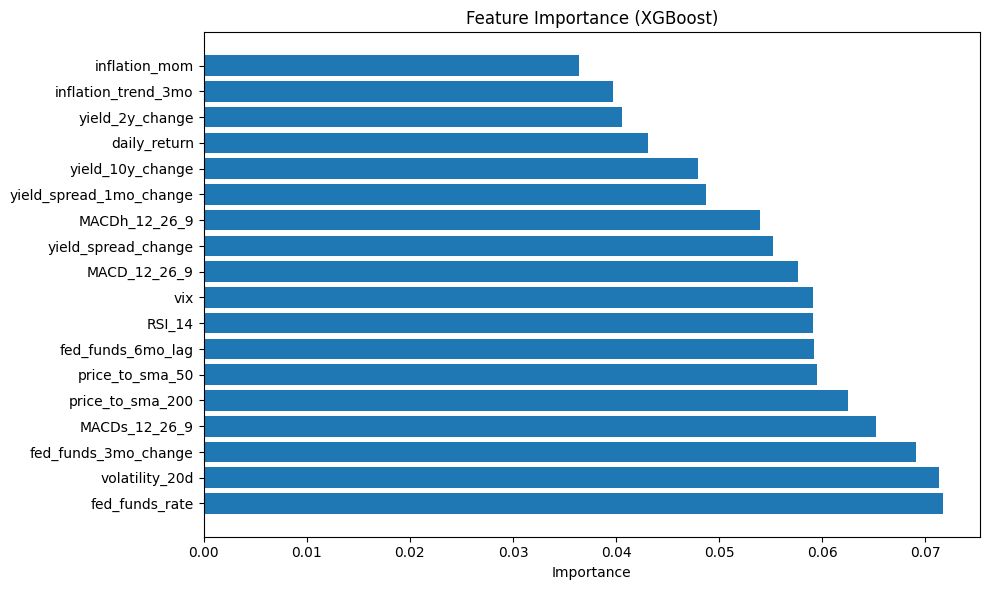

                    feature  importance
1            fed_funds_rate    0.071709
8            volatility_20d    0.071321
12     fed_funds_3mo_change    0.069063
6             MACDs_12_26_9    0.065165
10         price_to_sma_200    0.062519
9           price_to_sma_50    0.059476
14        fed_funds_6mo_lag    0.059227
3                    RSI_14    0.059136
0                       vix    0.059056
4              MACD_12_26_9    0.057674
17      yield_spread_change    0.055255
5             MACDh_12_26_9    0.053971
11  yield_spread_1mo_change    0.048720
15         yield_10y_change    0.047980
7              daily_return    0.043066
16          yield_2y_change    0.040598
13      inflation_trend_3mo    0.039706
2             inflation_mom    0.036360


In [38]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance (XGBoost)')
plt.tight_layout()
plt.show()

print(feature_importance)